# Training application model

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from anomaly_detection.parser.data_parsers import parse_application
from anomaly_detection.transformers import application_transformer

c:\Users\hp\AppData\Local\pypoetry\Cache\virtualenvs\anomaly-detection-mxkT3iGB-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/training/application"

model_path = project_folder / "src/anomaly_detection/models"

application_evtx_path = project_folder / "data/raw/93_applog.evtx"

application_evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_applog.evtx')

# Data preparation

In [3]:
application_training_records = parse_application(application_evtx_path)

application_training_records[0]

{'EventRecordID': 2899035,
 'timestamp': {'second_cos': np.float64(1.0),
  'month_sin': np.float64(1.2246467991473532e-16),
  'minute_sin': np.float64(-0.40673664307580015),
  'month_cos': np.float64(-1.0),
  'hour_cos': np.float64(-0.8660254037844387),
  'hour_sin': np.float64(0.49999999999999994),
  'day_cos': np.float64(-0.9009688679024191),
  'minute_cos': np.float64(0.913545457642601),
  'deltatime': Timedelta('0 days 00:00:20.289018'),
  'day_sin': np.float64(-0.433883739117558),
  'second_sin': np.float64(0.0)},
 'profile': {'event_id_frequency': np.float64(0.9653113448962184),
  'previous_event_id': 4,
  'execution_thread_id': None,
  'event_record_id': 2899035,
  'event_id': 4,
  'version': None,
  'correlation_activity_id': None},
 'data': {'context': 'php[8696] | PHP Warning: PHP Startup: Unable to load dynamic library \'php_pdo_sqlsrv_74_ts_x64.dll\' (tried: c:/wamp/bin/php/php7.4.0/ext/php_pdo_sqlsrv_74_ts_x64.dll (%1 n’est pas une application Win32 valide.), c:/wamp/bin/p

In [4]:
flat_application_training_record = [{**record['timestamp'], **record['profile'], **record['data']} for record in application_training_records]

flat_application_training_record[0]

{'second_cos': np.float64(1.0),
 'month_sin': np.float64(1.2246467991473532e-16),
 'minute_sin': np.float64(-0.40673664307580015),
 'month_cos': np.float64(-1.0),
 'hour_cos': np.float64(-0.8660254037844387),
 'hour_sin': np.float64(0.49999999999999994),
 'day_cos': np.float64(-0.9009688679024191),
 'minute_cos': np.float64(0.913545457642601),
 'deltatime': Timedelta('0 days 00:00:20.289018'),
 'day_sin': np.float64(-0.433883739117558),
 'second_sin': np.float64(0.0),
 'event_id_frequency': np.float64(0.9653113448962184),
 'previous_event_id': 4,
 'execution_thread_id': None,
 'event_record_id': 2899035,
 'event_id': 4,
 'version': None,
 'correlation_activity_id': None,
 'context': 'php[8696] | PHP Warning: PHP Startup: Unable to load dynamic library \'php_pdo_sqlsrv_74_ts_x64.dll\' (tried: c:/wamp/bin/php/php7.4.0/ext/php_pdo_sqlsrv_74_ts_x64.dll (%1 n’est pas une application Win32 valide.), c:/wamp/bin/php/php7.4.0/ext/php_php_pdo_sqlsrv_74_ts_x64.dll.dll (Le module spécifié est int

In [5]:
application_training_df = pd.DataFrame(flat_application_training_record)

application_training_df.head(10)

,second_cos,month_sin,minute_sin,month_cos,hour_cos,hour_sin,day_cos,minute_cos,deltatime,day_sin,second_sin,event_id_frequency,previous_event_id,execution_thread_id,event_record_id,event_id,version,correlation_activity_id,context,entity
0,1.000000,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:20.289018,-0.433884,0.000000,0.965311,4,NaN,2899035,4,NaN,None,php[8696] | PHP Warning: PHP Startup: Unable t...,NaN
1,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:02.662888,-0.433884,0.309017,0.965311,4,NaN,2899036,4,NaN,None,php[8736] | PHP Warning: PHP Startup: Unable t...,NaN
2,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00.062795,-0.433884,0.309017,0.965311,4,NaN,2899037,4,NaN,None,php[8456] | PHP Warning: PHP Startup: Unable t...,NaN
3,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00,-0.433884,0.309017,0.965311,4,NaN,2899038,4,NaN,None,php[4500] | PHP Warning: PHP Startup: Unable t...,NaN
4,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00.015626,-0.433884,0.309017,0.965311,4,NaN,2899039,4,NaN,None,php[3664] | PHP Warning: PHP Startup: Unable t...,NaN
5,1.000000,1.224647e-16,-0.207912,-1.0,-0.866025,0.5,-0.900969,0.978148,0 days 00:01:57.258522,-0.433884,0.000000,0.965311,4,NaN,2899040,4,NaN,None,php[1176] | PHP Warning: PHP Startup: Unable t...,NaN
6,0.951057,1.224647e-16,-0.207912,-1.0,-0.866025,0.5,-0.900969,0.978148,0 days 00:00:02.284295,-0.433884,0.309017,0.965311,4,NaN,2899041,4,NaN,None,php[3704] | PHP Warning: PHP Startup: Unable t...,NaN
7,0.951057,1.224647e-16,-0.207912,-1.0,-0.866025,0.5,-0.900969,0.978148,0 days 00:00:00,-0.433884,0.309017,0.965311,4,NaN,2899042,4,NaN,None,php[3664] | PHP Warning: PHP Startup: Unable t...,NaN
8,0.951057,1.224647e-16,-0.207912,-1.0,-0.866025,0.5,-0.900969,0.978148,0 days 00:00:00.015627,-0.433884,0.309017,0.965311,4,NaN,2899043,4,NaN,None,php[8788] | PHP Warning: PHP Startup: Unable t...,NaN
9,0.951057,1.224647e-16,-0.207912,-1.0,-0.866025,0.5,-0.900969,0.978148,0 days 00:00:00.015624,-0.433884,0.309017,0.965311,4,NaN,2899044,4,NaN,None,php[7804] | PHP Warning: PHP Startup: Unable t...,NaN


In [6]:
X_application = application_transformer.fit_transform(application_training_df)

X_application[0]

Batches: 100%|██████████| 27/27 [01:39<00:00,  3.69s/it]


array([ 2.02890180e+01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  1.85697103e+00, -8.12618971e-01,
       -7.77560234e+00, -8.89191568e-01,  1.86356044e+00, -7.34359860e-01,
        5.17447662e+00,  2.00604036e-01,  1.92621374e+00,  6.71876729e-01,
        6.24830246e-01, -3.24336320e-01,  9.61798355e-02, -7.71737635e-01,
       -1.74757987e-01,  6.33214951e-01, -1.15924668e+00,  1.38137114e+00,
        1.38693154e+00,  6.26840770e-01, -1.12300217e+00,  1.65585232e+00,
       -5.77044562e-02,  1.89756364e-01, -1.82851464e-01,  2.94307679e-01,
        4.37386427e-03,  5.70899367e-01, -6.28238499e-01, -1.08832014e+00,
        1.07793294e-01,  5.19071937e-01,  1.00000000e+00,  1.22464680e-16,
       -4.06736643e-01, -1.00000000e+00, -8.66025404e-01,  5.00000000e-01,
       -9.00968868e-01,  9.13545458e-01, -4.33883739e-01,  0.00000000e+00,
        9.65311345e-01,  4.00000000e+00,             nan,  2.89903500e+06,
        4.00000000e+00,  

In [7]:
X_application = np.nan_to_num(X_application)

X_application[0]

array([ 2.02890180e+01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.00000000e+00,  1.85697103e+00, -8.12618971e-01,
       -7.77560234e+00, -8.89191568e-01,  1.86356044e+00, -7.34359860e-01,
        5.17447662e+00,  2.00604036e-01,  1.92621374e+00,  6.71876729e-01,
        6.24830246e-01, -3.24336320e-01,  9.61798355e-02, -7.71737635e-01,
       -1.74757987e-01,  6.33214951e-01, -1.15924668e+00,  1.38137114e+00,
        1.38693154e+00,  6.26840770e-01, -1.12300217e+00,  1.65585232e+00,
       -5.77044562e-02,  1.89756364e-01, -1.82851464e-01,  2.94307679e-01,
        4.37386427e-03,  5.70899367e-01, -6.28238499e-01, -1.08832014e+00,
        1.07793294e-01,  5.19071937e-01,  1.00000000e+00,  1.22464680e-16,
       -4.06736643e-01, -1.00000000e+00, -8.66025404e-01,  5.00000000e-01,
       -9.00968868e-01,  9.13545458e-01, -4.33883739e-01,  0.00000000e+00,
        9.65311345e-01,  4.00000000e+00,  0.00000000e+00,  2.89903500e+06,
        4.00000000e+00,  

In [8]:
np.savetxt(output_path / "application_features.csv", X_application, delimiter=",", fmt='%.18e')

In [9]:
X_application = np.loadtxt(output_path / "application_features.csv", delimiter=",")

In [10]:
pd.DataFrame(X_application).describe().T

,count,mean,std,min,25%,50%,75%,max
0,21102.0,2.028902e+01,3.876192e+01,0.000000e+00,0.000000e+00,6.249800e-02,6.280957e+00,1.208190e+02
1,21102.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
3,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
4,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
5,21102.0,9.978675e-01,4.613082e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
6,21102.0,1.217644e+00,1.028787e+01,-7.231732e+01,2.595750e+00,3.239697e+00,3.508698e+00,4.569588e+00
7,21102.0,-1.641661e-01,4.498560e+00,-1.027030e+01,-9.014841e-01,-5.150616e-01,-1.352255e-01,7.030231e+01
8,21102.0,5.099170e-01,5.413198e+00,-1.199718e+01,-2.168721e-01,1.893482e+00,2.816087e+00,1.514100e+01
9,21102.0,-3.021119e-01,2.736514e+00,-3.024693e+01,-1.823594e+00,7.226629e-02,1.016668e+00,3.718245e+01


# Modeling

In [11]:
from sklearn.ensemble import IsolationForest

application_model = IsolationForest(
    n_estimators=512,
    contamination='auto',
    max_features=0.5,
    max_samples=512,
    n_jobs=-1,
)

application_model.fit(X_application)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",512
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [12]:
scores = application_model.score_samples(X_application)
predictions = application_model.predict(X_application)

In [13]:
results_df = application_training_df.copy()

results_df["anomaly_score"] = scores
results_df["prediction"] = predictions

results_df.head()

,second_cos,month_sin,minute_sin,month_cos,hour_cos,hour_sin,day_cos,minute_cos,deltatime,day_sin,...,previous_event_id,execution_thread_id,event_record_id,event_id,version,correlation_activity_id,context,entity,anomaly_score,prediction
0,1.000000,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:20.289018,-0.433884,...,4,NaN,2899035,4,NaN,None,php[8696] | PHP Warning: PHP Startup: Unable t...,NaN,-0.412505,1
1,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:02.662888,-0.433884,...,4,NaN,2899036,4,NaN,None,php[8736] | PHP Warning: PHP Startup: Unable t...,NaN,-0.399940,1
2,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00.062795,-0.433884,...,4,NaN,2899037,4,NaN,None,php[8456] | PHP Warning: PHP Startup: Unable t...,NaN,-0.393984,1
3,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00,-0.433884,...,4,NaN,2899038,4,NaN,None,php[4500] | PHP Warning: PHP Startup: Unable t...,NaN,-0.436296,1
4,0.951057,1.224647e-16,-0.406737,-1.0,-0.866025,0.5,-0.900969,0.913545,0 days 00:00:00.015626,-0.433884,...,4,NaN,2899039,4,NaN,None,php[3664] | PHP Warning: PHP Startup: Unable t...,NaN,-0.398797,1


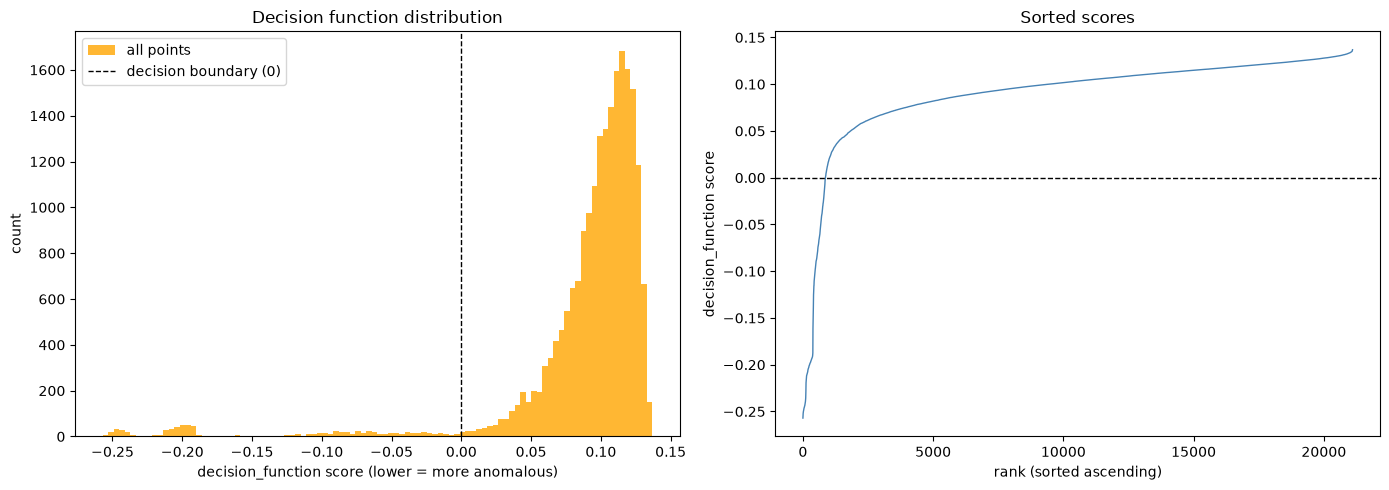

n points               : 21102
score min / max         : -0.2570 / 0.1368
score mean / std        : 0.0899 / 0.0539
   0.1th percentile     : -0.2496  (21 points below)
   0.5th percentile     : -0.2376  (105 points below)
     1th percentile     : -0.2038  (211 points below)
     2th percentile     : -0.1154  (422 points below)
     5th percentile     : 0.0236  (1055 points below)


array([0.08749545, 0.10006029, 0.10601617, ..., 0.0962468 , 0.06284041,
       0.06101968], shape=(21102,))

In [14]:
from anomaly_detection.utils.score_diagnostics import run_diagnostics

run_diagnostics(application_model, X_application, known_anomaly_mask=None)

In [15]:
decision_scores = application_model.decision_function(X_application)

new_contamination = np.mean(decision_scores < 0.05)

new_contamination

np.float64(0.08657947114017629)

In [16]:
anomalies_df = results_df[results_df['prediction'] == -1]

anomalies_df

,second_cos,month_sin,minute_sin,month_cos,hour_cos,hour_sin,day_cos,minute_cos,deltatime,day_sin,...,previous_event_id,execution_thread_id,event_record_id,event_id,version,correlation_activity_id,context,entity,anomaly_score,prediction
52,-0.951057,1.224647e-16,0.951057,-1.0,-0.965926,2.588190e-01,-0.900969,0.309017,0 days 00:00:24.150111,-0.433884,...,4,0.0,2899087,16394,0.0,None,,NaN,-0.709517,-1
53,0.994522,1.224647e-16,0.951057,-1.0,-0.965926,2.588190e-01,-0.900969,0.309017,0 days 00:00:32.624331,-0.433884,...,16394,0.0,2899088,16384,0.0,None,2126-05-19T11:12:59Z | RulesEngine,NaN,-0.579516,-1
136,-0.951057,1.224647e-16,-0.951057,-1.0,-0.965926,2.588190e-01,-0.900969,-0.309017,0 days 00:00:24.192895,-0.433884,...,4,0.0,2899171,16394,0.0,None,,NaN,-0.709835,-1
137,0.994522,1.224647e-16,-0.951057,-1.0,-0.965926,2.588190e-01,-0.900969,-0.309017,0 days 00:00:32.381811,-0.433884,...,16394,0.0,2899172,16384,0.0,None,2126-05-19T11:42:59Z | RulesEngine,NaN,-0.554638,-1
222,-0.951057,1.224647e-16,0.951057,-1.0,-1.000000,1.224647e-16,-0.900969,0.309017,0 days 00:00:24.160200,-0.433884,...,4,0.0,2899257,16394,0.0,None,,NaN,-0.708510,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20991,-0.809017,1.224647e-16,0.951057,-1.0,-0.707107,7.071068e-01,-0.222521,0.309017,0 days 00:00:20.376842,0.974928,...,4,0.0,2920026,16394,0.0,None,,NaN,-0.708155,-1
20992,0.669131,1.224647e-16,0.978148,-1.0,-0.707107,7.071068e-01,-0.222521,0.207912,0 days 00:00:44.093511,0.974928,...,16394,0.0,2920027,16384,0.0,None,2126-05-24T09:13:08Z | RulesEngine,NaN,-0.625163,-1
21075,-0.743145,1.224647e-16,-0.951057,-1.0,-0.707107,7.071068e-01,-0.222521,-0.309017,0 days 00:00:19.377177,0.974928,...,4,0.0,2920110,16394,0.0,None,,NaN,-0.713416,-1
21076,0.866025,1.224647e-16,-0.951057,-1.0,-0.707107,7.071068e-01,-0.222521,-0.309017,0 days 00:00:32.522568,0.974928,...,16394,0.0,2920111,16384,0.0,None,2126-05-24T09:42:55Z | RulesEngine,NaN,-0.607607,-1


In [17]:
anomalies_df['event_id'].value_counts()

event_id
16394    253
16384    253
4        132
4098      69
1001      57
64        45
1000      39
1704       7
100        7
9027       1
Name: count, dtype: int64

In [18]:
# Extract samples from each anomalous event ID
def pick_application_samples(n_samples_per_event):
    for event_id, group in anomalies_df.groupby("event_id"):
        print(f"\n{'=' * 60}")
        print(f"EventID {event_id}  --  {len(group)} anomalous rows")
        
        idx_min, idx_max = group.index.min(), group.index.max()
        idx_span = idx_max - idx_min
        print(f"row-index range: {idx_min} -> {idx_max}  (span: {idx_span})")
        print(f"{'=' * 60}")
    
        sample = group.sort_values("anomaly_score").head(n_samples_per_event)
    
        for _, row in sample.iterrows():
            print(f"\n  event_record_id: {row['event_record_id']}")
            print(f"  anomaly_score:    {row['anomaly_score']:.4f}")
 
            for col in [
                "event_id",
                "previous_event_id",
                "event_id_frequency",
                "version",
                "correlation_activity_id",
                "execution_thread_id",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")
            
            if "context" in row:
                print(f"  context:          {str(row['context'])[:300]}")
            if "entity" in row:
                print(f"  entity:           {row['entity']}")
 

In [19]:
from contextlib import redirect_stdout

with open(output_path / 'anomalous_samples.txt', 'w') as f:
    with redirect_stdout(f):
        pick_application_samples(5)

In [20]:
import joblib

joblib.dump(application_model, model_path / "application_model.joblib")

['c:\\Users\\hp\\Documents\\School\\anomaly-detection\\src\\anomaly_detection\\models\\application_model.joblib']